# NB02 — Chunking Strategy Comparison

This notebook compares two Markdown chunking strategies for the KDK documentation RAG pipeline:

- **Manual heading split**: split at `##` headings, re-split oversized sections with character overlap (current `scripts/chunk_md.py` approach)
- **LangChain RecursiveCharacterTextSplitter**: recursive splitting with heading-aware separators and controlled chunk size / overlap

Both strategies use the same embedding model (`nomic-ai/nomic-embed-text-v1.5` via SentenceTransformer) and the same vector database (Qdrant), so the only experimental variable is the chunking method.

**Sections:**
1. Configuration and test questions
2. Chunking strategies
3. Chunk statistics comparison
4. Embedding and Qdrant ingestion
5. Retrieval evaluation (LLM-as-Judge)
6. Visualization
7. Statistical test and conclusions

---
## 1. Configuration and Test Questions

In [ ]:
import json
import os
import re
import sys
import time
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from scipy.stats import wilcoxon
from tqdm.auto import tqdm

from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, PointStruct, VectorParams
from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv()

# Allow import of token_tracker from scripts/
ROOT_DIR = Path("..").resolve()
sys.path.insert(0, str(ROOT_DIR / "scripts"))
from token_tracker import TrackedClient

sns.set_theme(style="whitegrid", palette="muted")
matplotlib.rcParams["figure.dpi"] = 120

print("All imports OK")

In [ ]:
# ── Paths and constants ──
DOCS_DIR = ROOT_DIR / "data" / "kdk" / "docs"
OUTPUT_DIR = ROOT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

QDRANT_URL = "http://localhost:6333"
CLAUDE_MODEL = "claude-sonnet-4-20250514"
EMBEDDING_MODEL = "nomic-ai/nomic-embed-text-v1.5"

claude = TrackedClient(model=CLAUDE_MODEL, source="nb02")

MANUAL_COLLECTION = "nb02_manual_heading"
LANGCHAIN_COLLECTION = "nb02_langchain_rct"
RESET_ARTIFACTS = True

MANUAL_MAX_CHARS = 1500
MANUAL_OVERLAP_CHARS = 200
LANGCHAIN_CHUNK_SIZE = 1000
LANGCHAIN_CHUNK_OVERLAP = 200

TOP_K = 20
EMBED_BATCH_SIZE = 32

EVAL_PATH = OUTPUT_DIR / "nb02_retrieval_eval.json"

print(f"Docs dir: {DOCS_DIR} (exists={DOCS_DIR.exists()})")
print(f"Qdrant:   {QDRANT_URL}")
print(f"Judge:    Claude API / model={CLAUDE_MODEL}")
print(f"Embedding: {EMBEDDING_MODEL}")

In [3]:
# ── Test questions ──
# Priority questions from team feedback (how-to, component discovery, code lookup).
# Supplemented with factual and architecture questions for broader coverage.

QUESTIONS = [
    # How-to (from team: "how can I add a service / create an activity / configure components")
    {"id": 1,  "category": "howto",     "question": "How can I add a new service to my application?"},
    {"id": 2,  "category": "howto",     "question": "How can I create an activity to manage the items of a service?"},
    {"id": 3,  "category": "howto",     "question": "How should I configure components in KDK?"},
    {"id": 4,  "category": "howto",     "question": "How do I add a custom map layer to a KDK application?"},
    {"id": 5,  "category": "howto",     "question": "How do I register a hook on a service in KDK?"},

    # Component / utility / composable discovery (from team: "is there a composable for X?")
    {"id": 6,  "category": "discovery", "question": "Is there a composable for handling weather data in KDK?"},
    {"id": 7,  "category": "discovery", "question": "Does KDK provide a utility for managing map layers?"},
    {"id": 8,  "category": "discovery", "question": "Is there a component for uploading files in KDK?"},
    {"id": 9,  "category": "discovery", "question": "Does KDK have a mixin or composable for handling user selection on a map?"},
    {"id": 10, "category": "discovery", "question": "Is there a utility for converting geographic coordinates in KDK?"},

    # Code lookup (from team: "find all places where X is implemented")
    {"id": 11, "category": "code",      "question": "Where is the features service implemented in KDK?"},
    {"id": 12, "category": "code",      "question": "Which file defines the catalog service?"},
    {"id": 13, "category": "code",      "question": "What methods does the base activity mixin provide?"},
    {"id": 14, "category": "code",      "question": "How are permissions and abilities defined in KDK?"},
    {"id": 15, "category": "code",      "question": "What are the available map mixins and what do they do?"},

    # Factual / architecture
    {"id": 16, "category": "factual",   "question": "What does KDK stand for?"},
    {"id": 17, "category": "factual",   "question": "What is the main goal of the Kalisio Development Kit?"},
    {"id": 18, "category": "factual",   "question": "What kind of applications is KDK designed to help build?"},
    {"id": 19, "category": "factual",   "question": "What license is used by KDK?"},
    {"id": 20, "category": "factual",   "question": "What are the three main API parts of a KDK subsystem?"},

    # Architecture / concepts
    {"id": 21, "category": "arch",      "question": "How does KDK handle data segregation between organizations?"},
    {"id": 22, "category": "arch",      "question": "What role do services play in the KDK architecture?"},
    {"id": 23, "category": "arch",      "question": "How is the global architecture of a KDK application structured?"},
    {"id": 24, "category": "arch",      "question": "What is meant by context in KDK data segregation?"},
    {"id": 25, "category": "arch",      "question": "How does KDK separate client and server concerns?"},
]

print(f"Total test questions: {len(QUESTIONS)}")
for q in QUESTIONS[:5]:
    print(f"  [{q['id']:>2}] ({q['category']}) {q['question']}")

Total test questions: 25
  [ 1] (howto) How can I add a new service to my application?
  [ 2] (howto) How can I create an activity to manage the items of a service?
  [ 3] (howto) How should I configure components in KDK?
  [ 4] (howto) How do I add a custom map layer to a KDK application?
  [ 5] (howto) How do I register a hook on a service in KDK?


---
## 2. Chunking Strategies

In [4]:
# ── Strategy A: Manual heading split (mirrors scripts/chunk_md.py) ──

def get_doc_title(lines: list[str], fallback: str) -> str:
    for line in lines:
        if line.startswith("# ") and not line.startswith("## "):
            return line[2:].strip()
    return fallback


def split_oversized(text: str, max_chars: int = MANUAL_MAX_CHARS,
                    overlap: int = MANUAL_OVERLAP_CHARS) -> list[str]:
    if len(text) <= max_chars:
        return [text]
    parts = []
    start = 0
    while start < len(text):
        end = min(start + max_chars, len(text))
        parts.append(text[start:end].strip())
        if end >= len(text):
            break
        start = max(end - overlap, start + 1)
    return [p for p in parts if p]


def chunk_manual_heading(docs_dir: Path) -> list[dict]:
    chunks = []
    for filepath in sorted(docs_dir.rglob("*.md")):
        text = filepath.read_text(encoding="utf-8")
        lines = text.splitlines()
        rel_path = str(filepath.relative_to(docs_dir))
        doc_title = get_doc_title(lines, filepath.stem)

        sections = []
        current_title = doc_title
        current_lines = []
        for line in lines:
            if line.startswith("## "):
                if current_lines:
                    sections.append((current_title, "\n".join(current_lines).strip()))
                current_title = line[3:].strip()
                current_lines = []
            else:
                current_lines.append(line)
        if current_lines:
            sections.append((current_title, "\n".join(current_lines).strip()))

        chunk_index = 0
        for section_title, section_text in sections:
            for part in split_oversized(section_text):
                chunks.append({
                    "text": part,
                    "metadata": {
                        "source": rel_path,
                        "doc_title": doc_title,
                        "section_title": section_title,
                        "chunk_index": chunk_index,
                    },
                })
                chunk_index += 1
    return chunks


manual_chunks = chunk_manual_heading(DOCS_DIR)
print(f"Manual heading chunks: {len(manual_chunks)}")

Manual heading chunks: 823


In [5]:
# ── Strategy B: LangChain RecursiveCharacterTextSplitter ──

langchain_splitter = RecursiveCharacterTextSplitter(
    chunk_size=LANGCHAIN_CHUNK_SIZE,
    chunk_overlap=LANGCHAIN_CHUNK_OVERLAP,
    separators=["\n## ", "\n### ", "\n\n", "\n", " "],
)


def chunk_langchain_rct(docs_dir: Path) -> list[dict]:
    chunks = []
    for filepath in sorted(docs_dir.rglob("*.md")):
        text = filepath.read_text(encoding="utf-8")
        rel_path = str(filepath.relative_to(docs_dir))
        doc_title = filepath.stem
        for line in text.splitlines():
            if line.startswith("# ") and not line.startswith("## "):
                doc_title = line[2:].strip()
                break
        docs = langchain_splitter.create_documents(
            texts=[text],
            metadatas=[{"source": rel_path, "doc_title": doc_title, "section_title": doc_title}],
        )
        for doc in docs:
            chunks.append({
                "text": doc.page_content.strip(),
                "metadata": dict(doc.metadata),
            })
    return chunks


langchain_chunks = chunk_langchain_rct(DOCS_DIR)
print(f"LangChain RCT chunks: {len(langchain_chunks)}")

LangChain RCT chunks: 873


---
## 3. Chunk Statistics Comparison

In [6]:
manual_lengths = [len(c["text"]) for c in manual_chunks]
lc_lengths = [len(c["text"]) for c in langchain_chunks]

stats = pd.DataFrame({
    "Metric": ["Total chunks", "Mean length (chars)", "Median length", "Max length",
               "Min length", "Std dev", "Chunks < 50 chars", "Chunks > 1500 chars"],
    "Manual (## split)": [
        len(manual_lengths),
        f"{np.mean(manual_lengths):.0f}",
        f"{np.median(manual_lengths):.0f}",
        max(manual_lengths),
        min(manual_lengths),
        f"{np.std(manual_lengths):.0f}",
        sum(1 for l in manual_lengths if l < 50),
        sum(1 for l in manual_lengths if l > 1500),
    ],
    "LangChain (RCT 1000/200)": [
        len(lc_lengths),
        f"{np.mean(lc_lengths):.0f}",
        f"{np.median(lc_lengths):.0f}",
        max(lc_lengths),
        min(lc_lengths),
        f"{np.std(lc_lengths):.0f}",
        sum(1 for l in lc_lengths if l < 50),
        sum(1 for l in lc_lengths if l > 1500),
    ],
})
print(stats.to_string(index=False))

             Metric Manual (## split) LangChain (RCT 1000/200)
       Total chunks               823                      873
Mean length (chars)               650                      604
      Median length               400                      660
         Max length              1500                      999
         Min length                 0                        3
            Std dev               564                      305
  Chunks < 50 chars               103                       45
Chunks > 1500 chars                 0                        0


/tmp/ipykernel_352942/1808064022.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=box_data, x="strategy", y="length",


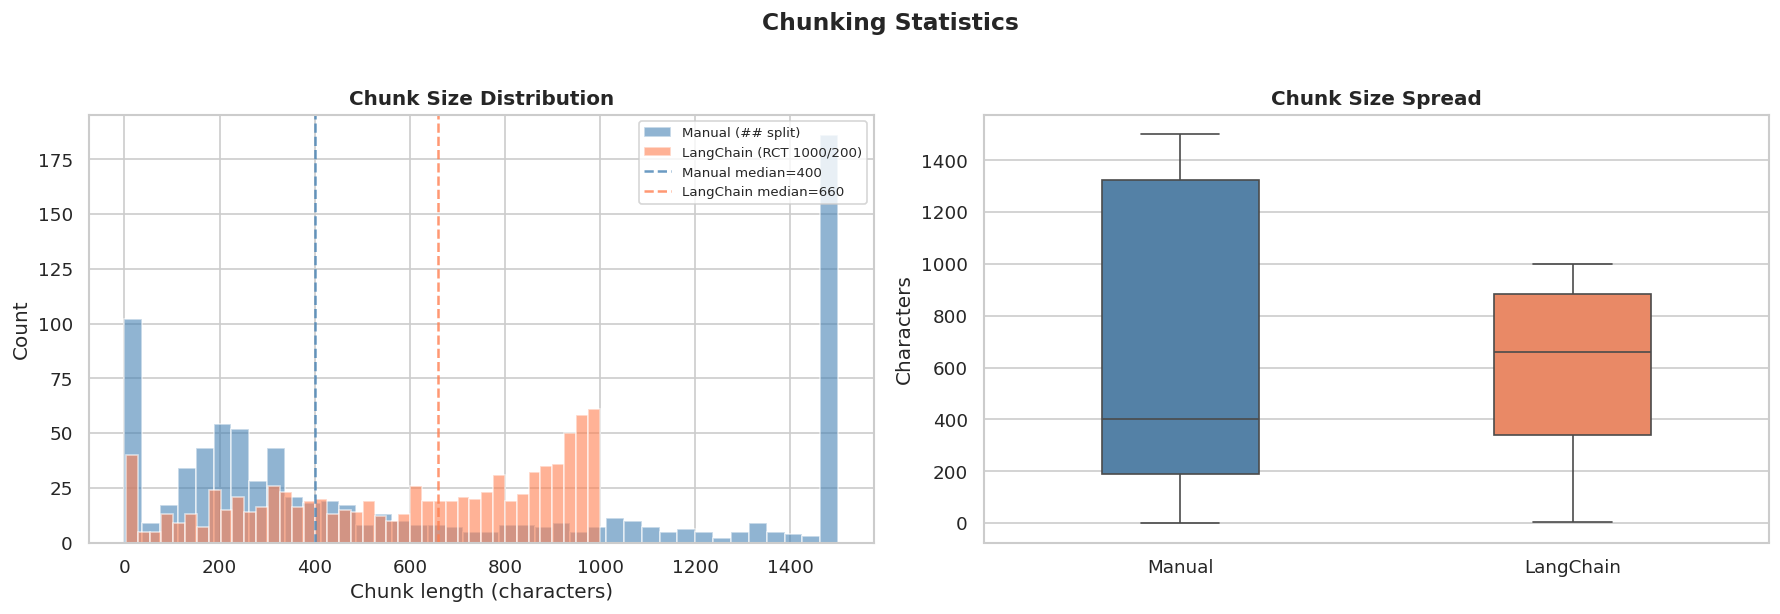

In [7]:
# ── Chunk size distribution histogram ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) Overlapping histogram
ax = axes[0]
ax.hist(manual_lengths, bins=40, alpha=0.6, label="Manual (## split)", color="steelblue", edgecolor="white")
ax.hist(lc_lengths, bins=40, alpha=0.6, label="LangChain (RCT 1000/200)", color="coral", edgecolor="white")
ax.axvline(np.median(manual_lengths), color="steelblue", linestyle="--", alpha=0.8, label=f"Manual median={np.median(manual_lengths):.0f}")
ax.axvline(np.median(lc_lengths), color="coral", linestyle="--", alpha=0.8, label=f"LangChain median={np.median(lc_lengths):.0f}")
ax.set_xlabel("Chunk length (characters)")
ax.set_ylabel("Count")
ax.set_title("Chunk Size Distribution", fontsize=12, fontweight="bold")
ax.legend(fontsize=8)

# (b) Box plot of chunk sizes
ax = axes[1]
box_data = pd.DataFrame({
    "length": manual_lengths + lc_lengths,
    "strategy": ["Manual"] * len(manual_lengths) + ["LangChain"] * len(lc_lengths),
})
sns.boxplot(data=box_data, x="strategy", y="length",
            palette={"Manual": "steelblue", "LangChain": "coral"}, ax=ax, width=0.4)
ax.set_title("Chunk Size Spread", fontsize=12, fontweight="bold")
ax.set_ylabel("Characters")
ax.set_xlabel("")

plt.suptitle("Chunking Statistics", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Embedding and Qdrant Ingestion

Both chunk sets are embedded with the same model (`nomic-ai/nomic-embed-text-v1.5`) so the only variable is the chunking strategy.

In [8]:
# ── Load embedding model ──
print(f"Loading embedding model: {EMBEDDING_MODEL}")
embed_model = SentenceTransformer(EMBEDDING_MODEL, trust_remote_code=True)
print(f"Model loaded. Embedding dimension: {embed_model.get_sentence_embedding_dimension()}")

Loading embedding model: nomic-ai/nomic-embed-text-v1.5


<All keys matched successfully>


Model loaded. Embedding dimension: 768


In [9]:
# ── Helper functions ──
qdrant = QdrantClient(url=QDRANT_URL)


def reset_collections():
    for collection in [MANUAL_COLLECTION, LANGCHAIN_COLLECTION]:
        if qdrant.collection_exists(collection):
            qdrant.delete_collection(collection)
            print(f"Deleted collection: {collection}")
    if EVAL_PATH.exists():
        EVAL_PATH.unlink()
        print(f"Removed cache: {EVAL_PATH.name}")


def embed_texts(texts: list[str], batch_size: int = EMBED_BATCH_SIZE) -> np.ndarray:
    vectors = []
    for start in tqdm(range(0, len(texts), batch_size), desc="Embedding"):
        batch = texts[start : start + batch_size]
        vectors.append(embed_model.encode(batch, show_progress_bar=False))
    return np.vstack(vectors)


def ingest_chunks(collection_name: str, chunks: list[dict]) -> None:
    texts = [c["text"] for c in chunks]
    vectors = embed_texts(texts)

    if qdrant.collection_exists(collection_name):
        qdrant.delete_collection(collection_name)
    qdrant.create_collection(
        collection_name=collection_name,
        vectors_config=VectorParams(size=vectors.shape[1], distance=Distance.COSINE),
    )

    points = [
        PointStruct(
            id=i,
            vector=vectors[i].tolist(),
            payload={"text": chunks[i]["text"], **chunks[i]["metadata"]},
        )
        for i in range(len(chunks))
    ]
    qdrant.upsert(collection_name=collection_name, points=points)
    info = qdrant.get_collection(collection_name)
    print(f"{collection_name}: {info.points_count} points (dim={vectors.shape[1]})")


if RESET_ARTIFACTS:
    reset_collections()

ingest_chunks(MANUAL_COLLECTION, manual_chunks)
ingest_chunks(LANGCHAIN_COLLECTION, langchain_chunks)

Deleted collection: nb02_manual_heading
Deleted collection: nb02_langchain_rct
Removed cache: nb02_retrieval_eval.json


Embedding: 100%|██████████| 26/26 [05:22<00:00, 12.41s/it]


nb02_manual_heading: 823 points (dim=768)


Embedding: 100%|██████████| 28/28 [03:47<00:00,  8.12s/it]


nb02_langchain_rct: 873 points (dim=768)


---
## 5. Retrieval Evaluation (LLM-as-Judge)

For each question, retrieve top-K chunks from both collections. An LLM judge determines:
- `first_relevant_rank`: the first chunk rank that contains enough information to answer
- `has_answer_top1`, `has_answer_top5`, `has_answer_top20`: hit booleans

MRR (Mean Reciprocal Rank) is computed from `first_relevant_rank`.

In [ ]:
# ── Retrieval and judging functions ──

JUDGE_PROMPT = """You are evaluating retrieval quality for a RAG system.

Question:
{question}

Retrieved chunks:
{retrieved_chunks}

Determine the first chunk rank that contains enough information to answer the question directly and faithfully from the retrieved text alone.

Rules:
- A chunk is relevant only if it contains the answer, not just related terminology.
- If no chunk in the list is sufficient, return null for first_relevant_rank.
- Also return booleans for has_answer_top1, has_answer_top5, has_answer_top20.

Return ONLY a JSON object with keys:
first_relevant_rank, has_answer_top1, has_answer_top5, has_answer_top20, rationale
"""


def retrieve(question: str, collection_name: str, k: int = TOP_K):
    query_vector = embed_model.encode(question).tolist()
    return qdrant.query_points(
        collection_name=collection_name,
        query=query_vector,
        limit=k,
        with_payload=True,
    ).points


def format_chunks_for_judge(points) -> str:
    blocks = []
    for rank, point in enumerate(points, start=1):
        payload = point.payload or {}
        blocks.append(
            f"[Rank {rank}] score={point.score:.4f}\n"
            f"Source: {payload.get('source', '')}\n"
            f"Section: {payload.get('section_title', '')}\n"
            f"Content:\n{payload.get('text', '')[:900]}"
        )
    return "\n\n".join(blocks)


def parse_judge_json(text: str) -> dict:
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", text, re.DOTALL)
        if match:
            return json.loads(match.group())
        return {}


def judge_retrieval(question: str, points) -> dict:
    prompt = JUDGE_PROMPT.format(
        question=question,
        retrieved_chunks=format_chunks_for_judge(points),
    )
    raw = claude.ask(prompt, max_tokens=512)
    data = parse_judge_json(raw)

    rank = data.get("first_relevant_rank")
    data["first_relevant_rank"] = int(rank) if rank is not None else None
    for key in ["has_answer_top1", "has_answer_top5", "has_answer_top20"]:
        data[key] = bool(data.get(key, False))
    return data


print("Retrieval and judge functions ready.")

In [11]:
# ── Run evaluation on all questions ──
strategy_map = {
    "manual_heading": MANUAL_COLLECTION,
    "langchain_rct": LANGCHAIN_COLLECTION,
}

if EVAL_PATH.exists() and not RESET_ARTIFACTS:
    eval_results = json.loads(EVAL_PATH.read_text(encoding="utf-8"))
    print(f"Loaded {len(eval_results)} cached results")
else:
    eval_results = []

done = {(r["question_id"], r["strategy"]) for r in eval_results}

for q in tqdm(QUESTIONS, desc="Evaluating retrieval"):
    for strategy, collection in strategy_map.items():
        if (q["id"], strategy) in done:
            continue
        t0 = time.time()
        points = retrieve(q["question"], collection, TOP_K)
        retrieval_time = time.time() - t0
        judged = judge_retrieval(q["question"], points)
        eval_results.append({
            "question_id": q["id"],
            "category": q["category"],
            "question": q["question"],
            "strategy": strategy,
            "retrieval_time": retrieval_time,
            "first_relevant_rank": judged.get("first_relevant_rank"),
            "has_answer_top1": judged.get("has_answer_top1", False),
            "has_answer_top5": judged.get("has_answer_top5", False),
            "has_answer_top20": judged.get("has_answer_top20", False),
            "judge_rationale": judged.get("rationale", ""),
        })
        # Checkpoint
        EVAL_PATH.write_text(json.dumps(eval_results, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"Total evaluation rows: {len(eval_results)}")

Evaluating retrieval: 100%|██████████| 25/25 [04:16<00:00, 10.28s/it]

Total evaluation rows: 50


In [12]:
# ── Build evaluation DataFrame ──
eval_df = pd.DataFrame(eval_results)
eval_df["rank_for_metrics"] = eval_df["first_relevant_rank"].fillna(TOP_K + 1)
eval_df["reciprocal_rank"] = eval_df["first_relevant_rank"].apply(
    lambda x: 1 / x if pd.notnull(x) else 0.0
)

# Aggregate metrics
metrics = eval_df.groupby("strategy").agg(
    hit_at_1=("has_answer_top1", "mean"),
    hit_at_5=("has_answer_top5", "mean"),
    hit_at_20=("has_answer_top20", "mean"),
    mean_first_rank=("rank_for_metrics", "mean"),
    median_first_rank=("rank_for_metrics", "median"),
    mrr=("reciprocal_rank", "mean"),
    mean_retrieval_time=("retrieval_time", "mean"),
).round(3)

print("=== Overall Retrieval Metrics ===")
print(metrics.to_string())

=== Overall Retrieval Metrics ===
                hit_at_1  hit_at_5  hit_at_20  mean_first_rank  median_first_rank    mrr  mean_retrieval_time
strategy                                                                                                     
langchain_rct       0.44      1.00       1.00             3.16                2.0  0.592                0.032
manual_heading      0.48      0.96       0.96             3.84                2.0  0.590                0.034


In [13]:
# ── Metrics by question category ──
cat_metrics = eval_df.groupby(["category", "strategy"]).agg(
    hit_at_1=("has_answer_top1", "mean"),
    hit_at_5=("has_answer_top5", "mean"),
    mrr=("reciprocal_rank", "mean"),
    mean_first_rank=("rank_for_metrics", "mean"),
).round(3)

print("=== Retrieval Metrics by Category ===")
print(cat_metrics.to_string())

=== Retrieval Metrics by Category ===
                          hit_at_1  hit_at_5    mrr  mean_first_rank
category  strategy                                                  
arch      langchain_rct        0.4       1.0  0.600              2.4
          manual_heading       0.4       1.0  0.579              3.0
code      langchain_rct        0.4       1.0  0.545              3.2
          manual_heading       0.4       1.0  0.422              4.8
discovery langchain_rct        0.2       1.0  0.432              3.8
          manual_heading       0.4       0.8  0.550              5.8
factual   langchain_rct        0.6       1.0  0.643              4.4
          manual_heading       0.6       1.0  0.651              3.8
howto     langchain_rct        0.6       1.0  0.740              2.0
          manual_heading       0.6       1.0  0.750              1.8


---
## 6. Visualization

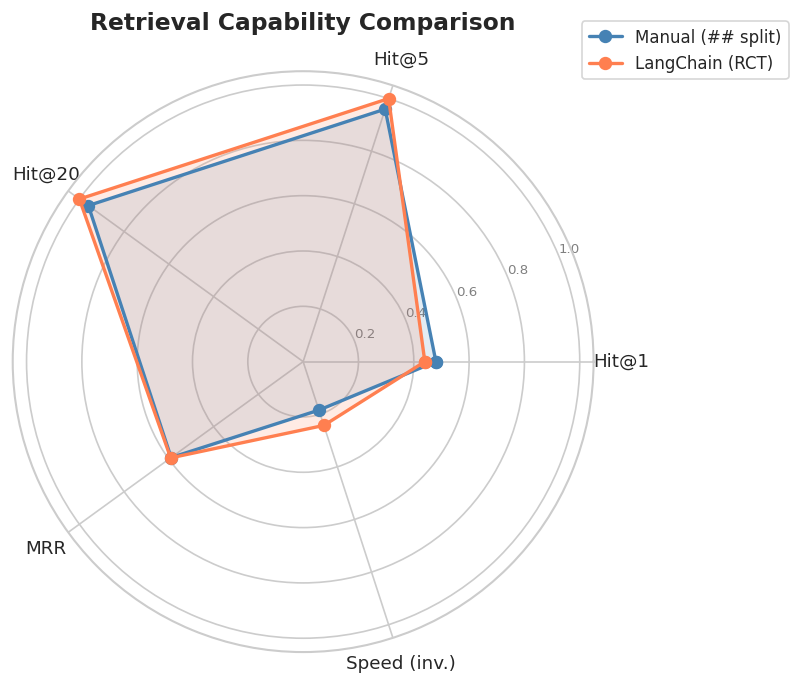

In [14]:
# ── Chart 1: Radar chart — overall retrieval capability comparison ──
def radar_chart(metrics_df, eval_df):
    categories = ["Hit@1", "Hit@5", "Hit@20", "MRR", "Speed (inv.)"]
    n = len(categories)

    m = metrics_df.loc["manual_heading"]
    lc = metrics_df.loc["langchain_rct"]

    # Normalize speed: invert so higher = faster, scale to 0-1
    max_time = eval_df["retrieval_time"].max()
    m_speed = 1 - eval_df[eval_df["strategy"] == "manual_heading"]["retrieval_time"].mean() / max_time if max_time > 0 else 0.5
    lc_speed = 1 - eval_df[eval_df["strategy"] == "langchain_rct"]["retrieval_time"].mean() / max_time if max_time > 0 else 0.5

    vals_manual = [m["hit_at_1"], m["hit_at_5"], m["hit_at_20"], m["mrr"], m_speed]
    vals_lc = [lc["hit_at_1"], lc["hit_at_5"], lc["hit_at_20"], lc["mrr"], lc_speed]

    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    vals_manual += vals_manual[:1]
    vals_lc += vals_lc[:1]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    ax.plot(angles, vals_manual, "o-", linewidth=2, label="Manual (## split)", color="steelblue", markersize=7)
    ax.fill(angles, vals_manual, alpha=0.15, color="steelblue")
    ax.plot(angles, vals_lc, "o-", linewidth=2, label="LangChain (RCT)", color="coral", markersize=7)
    ax.fill(angles, vals_lc, alpha=0.15, color="coral")
    ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8, color="grey")
    ax.set_title("Retrieval Capability Comparison", pad=25, fontsize=14, fontweight="bold")
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=10)
    plt.tight_layout()
    plt.show()

radar_chart(metrics, eval_df)

/tmp/ipykernel_352942/2173562763.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=mrr_data, x="strategy", y="mrr", palette=PALETTE, ax=ax,
/tmp/ipykernel_352942/2173562763.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([LABELS.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])
/tmp/ipykernel_352942/2173562763.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eval_df, x="strategy", y="rank_for_metrics", palette=PALETTE, ax=ax,
/tmp/ipykernel_352942/2173562763.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.

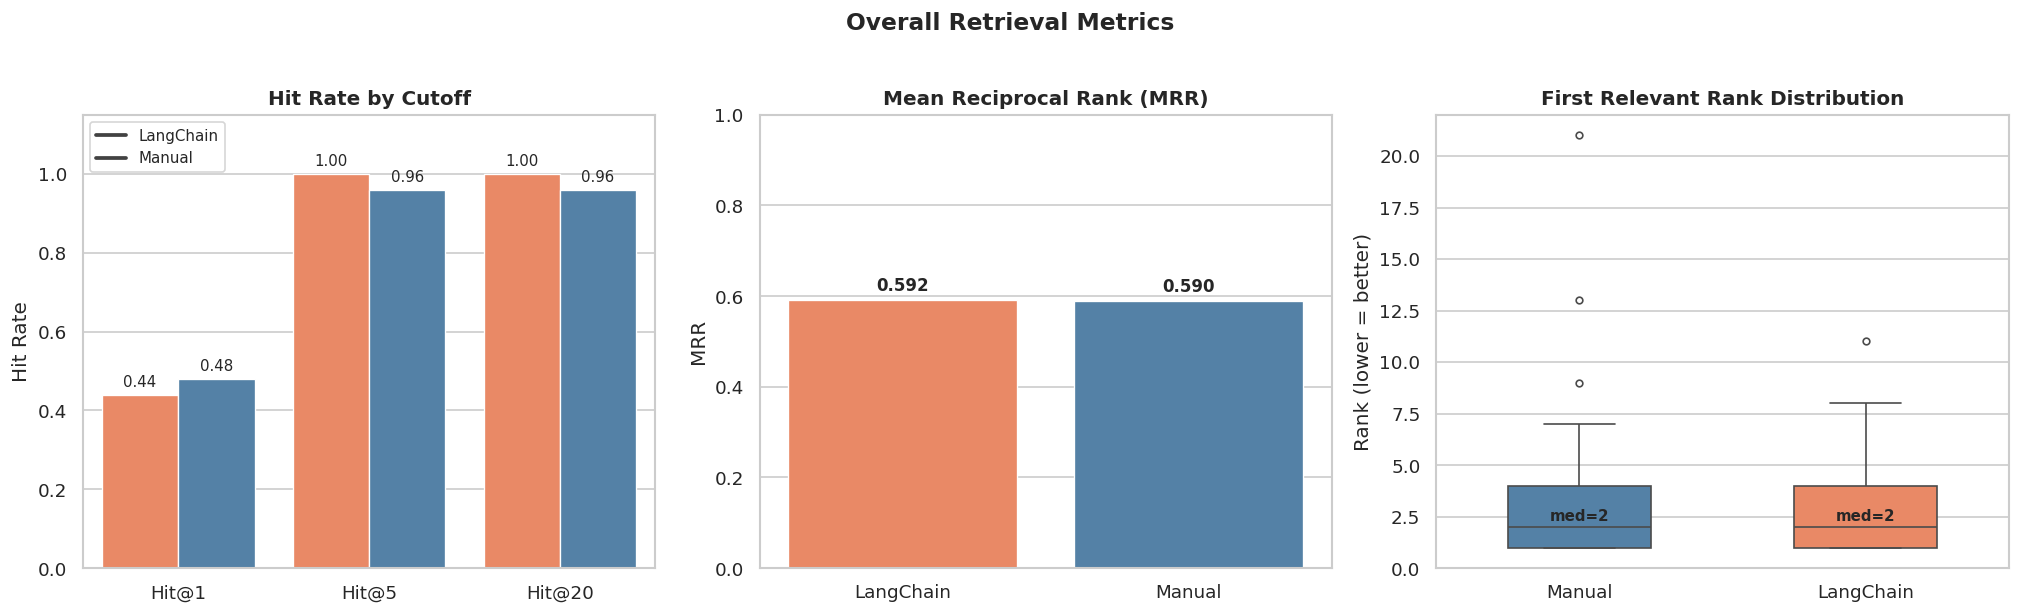

In [15]:
# ── Chart 2: Hit rates, MRR bars, and rank distribution ──
PALETTE = {"manual_heading": "steelblue", "langchain_rct": "coral"}
LABELS = {"manual_heading": "Manual", "langchain_rct": "LangChain"}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) Hit rate bars
hit_data = metrics.reset_index()[["strategy", "hit_at_1", "hit_at_5", "hit_at_20"]].melt(
    id_vars="strategy", var_name="metric", value_name="value"
)
hit_data["metric"] = hit_data["metric"].map({"hit_at_1": "Hit@1", "hit_at_5": "Hit@5", "hit_at_20": "Hit@20"})
ax = axes[0]
bars = sns.barplot(data=hit_data, x="metric", y="value", hue="strategy",
                   palette=PALETTE, ax=ax, edgecolor="white", linewidth=0.8)
ax.set_ylim(0, 1.15)
ax.set_title("Hit Rate by Cutoff", fontsize=12, fontweight="bold")
ax.set_ylabel("Hit Rate")
ax.set_xlabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=9, padding=3)
ax.legend(labels=[LABELS[l.get_text()] for l in ax.get_legend().get_texts()],
          title="", fontsize=9)

# (b) MRR comparison
ax = axes[1]
mrr_data = metrics.reset_index()[["strategy", "mrr"]]
bars = sns.barplot(data=mrr_data, x="strategy", y="mrr", palette=PALETTE, ax=ax,
                   edgecolor="white", linewidth=0.8)
ax.set_ylim(0, 1)
ax.set_title("Mean Reciprocal Rank (MRR)", fontsize=12, fontweight="bold")
ax.set_ylabel("MRR")
ax.set_xlabel("")
ax.set_xticklabels([LABELS.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=10, fontweight="bold", padding=3)

# (c) First relevant rank boxplot
ax = axes[2]
sns.boxplot(data=eval_df, x="strategy", y="rank_for_metrics", palette=PALETTE, ax=ax,
            width=0.5, fliersize=4)
ax.set_title(f"First Relevant Rank Distribution", fontsize=12, fontweight="bold")
ax.set_ylabel("Rank (lower = better)")
ax.set_xlabel("")
ax.set_xticklabels([LABELS.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])
# Add median annotations
for i, strategy in enumerate(["manual_heading", "langchain_rct"]):
    median_val = eval_df[eval_df["strategy"] == strategy]["rank_for_metrics"].median()
    ax.text(i, median_val + 0.3, f"med={median_val:.0f}", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Overall Retrieval Metrics", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

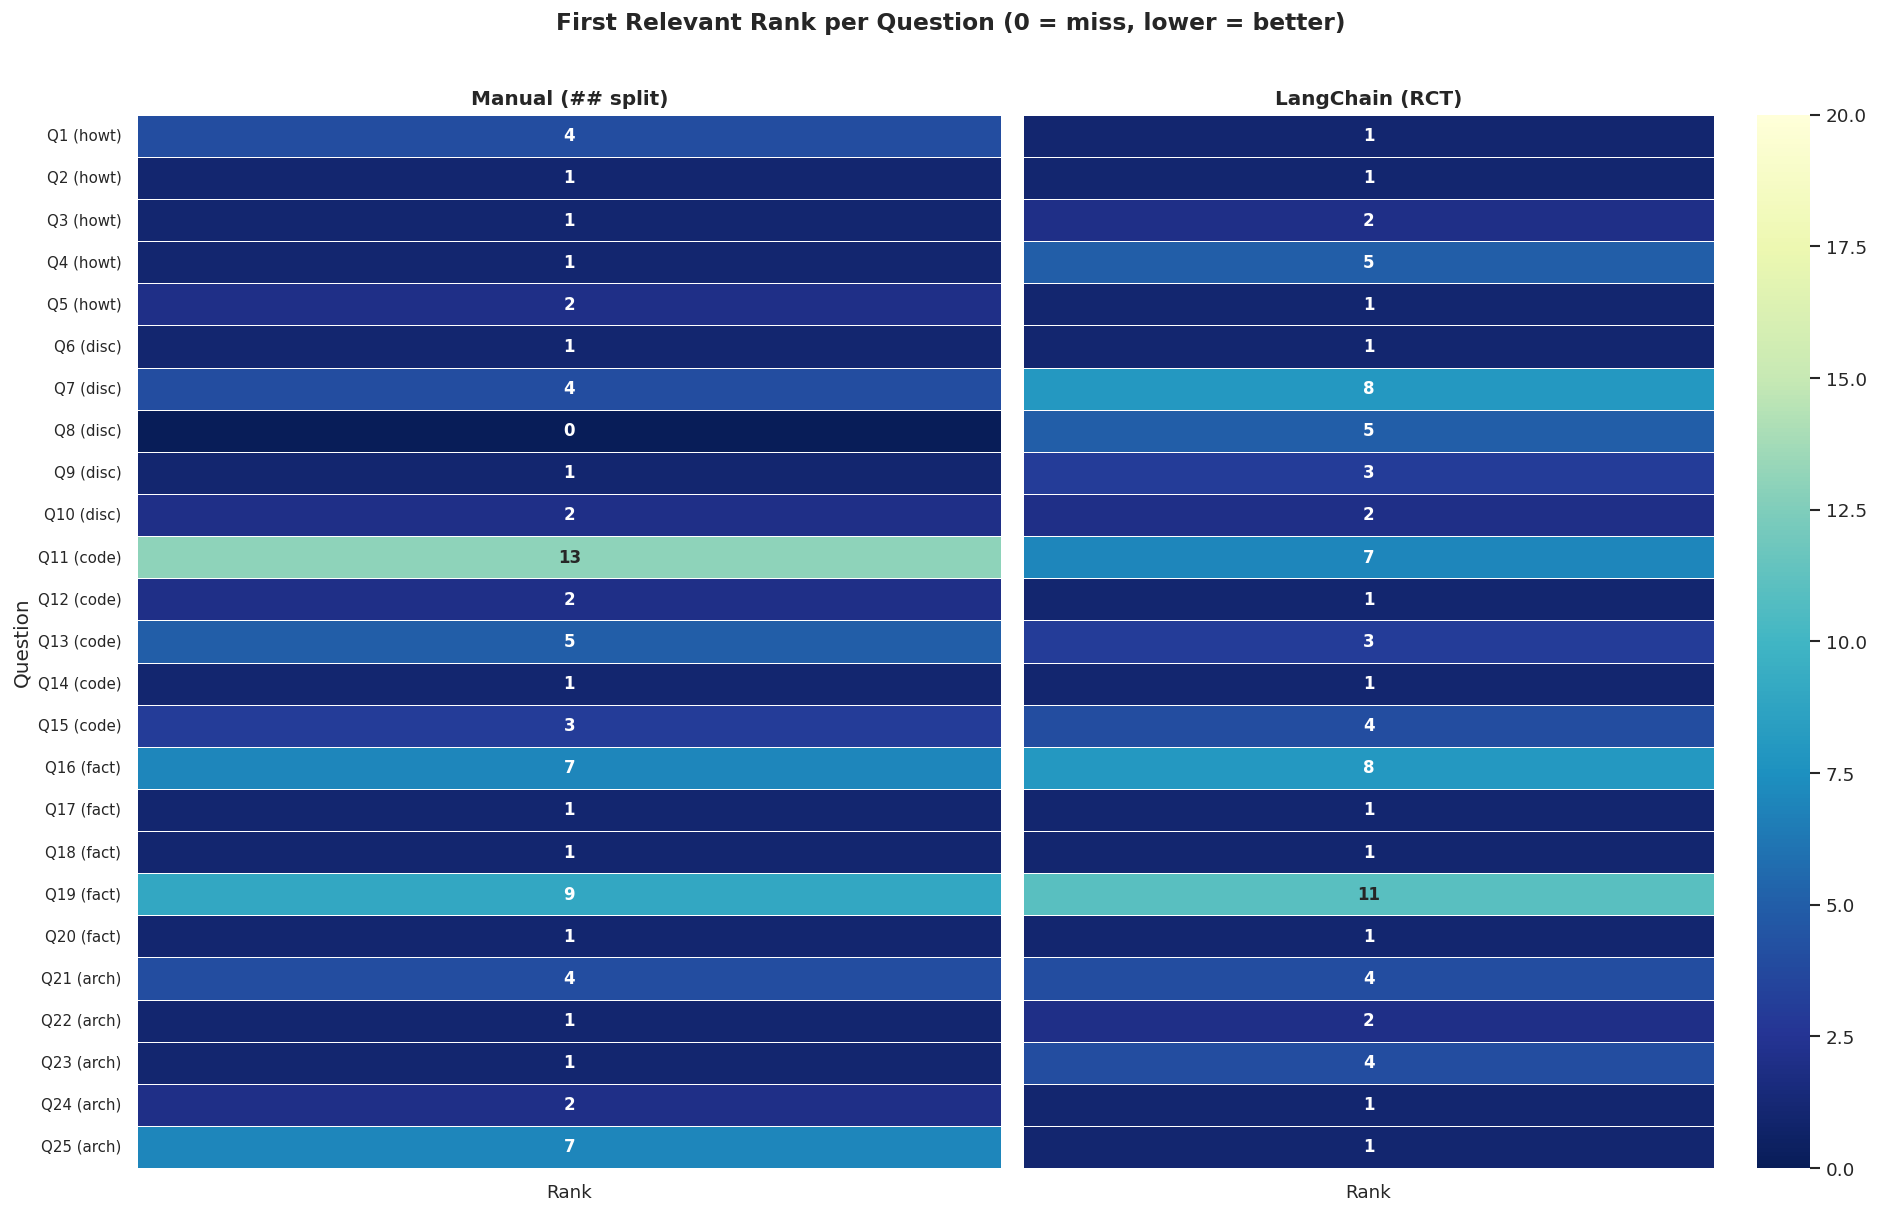

In [16]:
# ── Chart 3: Per-question heatmap with question labels ──
fig, axes = plt.subplots(1, 2, figsize=(16, 10), sharey=True)

# Build label mapping: question_id → short label
q_labels = {q["id"]: f"Q{q['id']} ({q['category'][:4]})" for q in QUESTIONS}
cat_colors = {"howto": "#2ecc71", "discovery": "#f39c12", "code": "#9b59b6",
              "factual": "#3498db", "arch": "#e74c3c"}

for idx, (strategy, title, ax) in enumerate(zip(
    ["manual_heading", "langchain_rct"],
    ["Manual (## split)", "LangChain (RCT)"],
    axes,
)):
    sub = eval_df[eval_df["strategy"] == strategy].sort_values("question_id")
    heatmap_data = sub.set_index("question_id")[["first_relevant_rank"]].fillna(0)
    heatmap_data.index = [q_labels.get(i, str(i)) for i in heatmap_data.index]
    heatmap_data.columns = ["Rank"]
    sns.heatmap(
        heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu_r", vmin=0, vmax=TOP_K,
        ax=ax, cbar=idx == 1, linewidths=0.5, linecolor="white",
        annot_kws={"fontsize": 10, "fontweight": "bold"},
    )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("" if idx == 1 else "Question")
    ax.tick_params(axis="y", labelsize=9)

fig.suptitle("First Relevant Rank per Question (0 = miss, lower = better)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

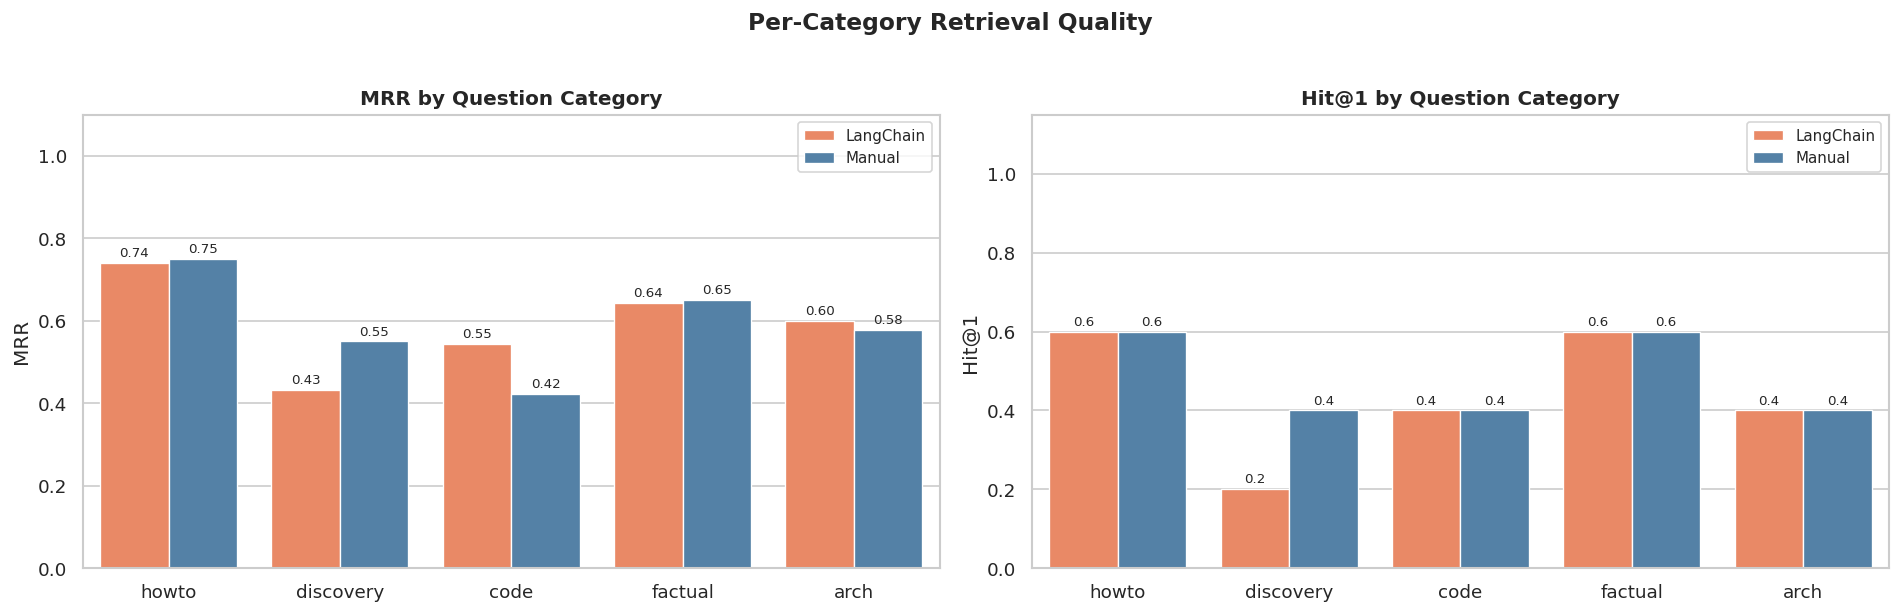

In [17]:
# ── Chart 4: Per-category MRR + Hit@1 comparison ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cat_plot = cat_metrics.reset_index()
cat_order = ["howto", "discovery", "code", "factual", "arch"]

# (a) MRR by category
ax = axes[0]
sns.barplot(data=cat_plot, x="category", y="mrr", hue="strategy", order=cat_order,
            palette=PALETTE, ax=ax, edgecolor="white", linewidth=0.8)
ax.set_ylim(0, 1.1)
ax.set_title("MRR by Question Category", fontsize=12, fontweight="bold")
ax.set_ylabel("MRR")
ax.set_xlabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, [LABELS.get(l, l) for l in labels], title="", fontsize=9)

# (b) Hit@1 by category
ax = axes[1]
sns.barplot(data=cat_plot, x="category", y="hit_at_1", hue="strategy", order=cat_order,
            palette=PALETTE, ax=ax, edgecolor="white", linewidth=0.8)
ax.set_ylim(0, 1.15)
ax.set_title("Hit@1 by Question Category", fontsize=12, fontweight="bold")
ax.set_ylabel("Hit@1")
ax.set_xlabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=8, padding=2)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, [LABELS.get(l, l) for l in labels], title="", fontsize=9)

plt.suptitle("Per-Category Retrieval Quality", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

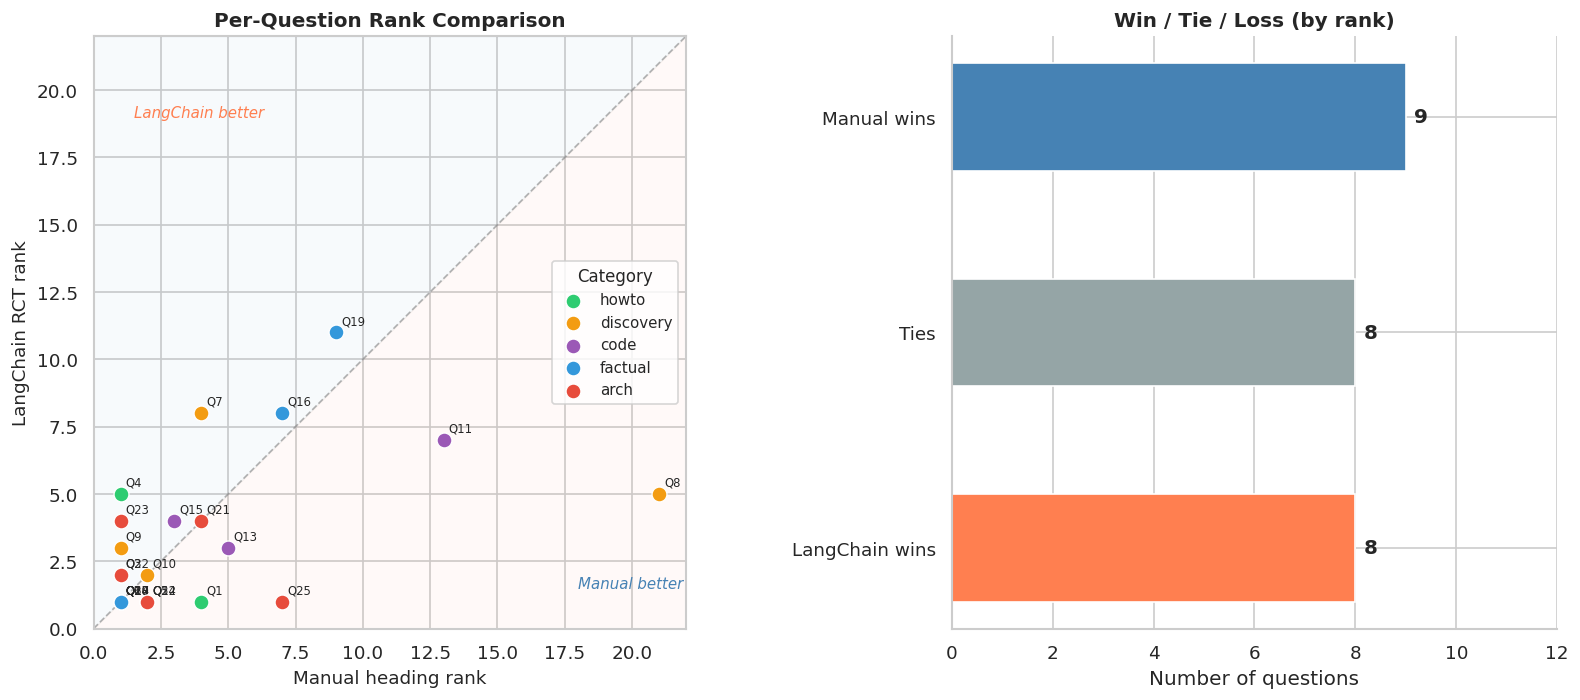

In [19]:
# ── Chart 5: Per-question rank scatter + Win/Tie/Loss bar ──

# Compute rank arrays (needed for Win/Tie/Loss)
manual_ranks = eval_df[eval_df["strategy"] == "manual_heading"].sort_values("question_id")["rank_for_metrics"].values
lc_ranks = eval_df[eval_df["strategy"] == "langchain_rct"].sort_values("question_id")["rank_for_metrics"].values

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1.2, 0.8]})

# (a) Scatter: per-question rank comparison
rank_pivot = eval_df.pivot(
    index="question_id", columns="strategy", values="rank_for_metrics"
).reset_index()
q_df = pd.DataFrame(QUESTIONS)[["id", "category"]].rename(columns={"id": "question_id"})
rank_pivot = rank_pivot.merge(q_df, on="question_id")

cat_colors = {"howto": "#2ecc71", "discovery": "#f39c12", "code": "#9b59b6",
              "factual": "#3498db", "arch": "#e74c3c"}

ax = axes[0]
for cat, color in cat_colors.items():
    sub = rank_pivot[rank_pivot["category"] == cat]
    ax.scatter(sub["manual_heading"], sub["langchain_rct"],
               c=color, label=cat, s=80, zorder=3, edgecolors="white", linewidth=0.8)
    # Label each point with question ID
    for _, row in sub.iterrows():
        ax.annotate(f"Q{int(row['question_id'])}", (row["manual_heading"], row["langchain_rct"]),
                    fontsize=7, ha="left", va="bottom", xytext=(3, 3), textcoords="offset points")

ax.plot([0, TOP_K + 2], [0, TOP_K + 2], linestyle="--", color="grey", alpha=0.6, linewidth=1)
ax.fill_between([0, TOP_K + 2], [0, TOP_K + 2], TOP_K + 2, alpha=0.04, color="steelblue", label="_nolegend_")
ax.fill_between([0, TOP_K + 2], 0, [0, TOP_K + 2], alpha=0.04, color="coral", label="_nolegend_")
ax.text(TOP_K - 2, 1.5, "Manual better", fontsize=9, color="steelblue", fontstyle="italic")
ax.text(1.5, TOP_K - 1, "LangChain better", fontsize=9, color="coral", fontstyle="italic")
ax.set_xlabel("Manual heading rank", fontsize=11)
ax.set_ylabel("LangChain RCT rank", fontsize=11)
ax.set_title("Per-Question Rank Comparison", fontsize=12, fontweight="bold")
ax.legend(title="Category", fontsize=9, title_fontsize=10)
ax.set_xlim(0, TOP_K + 2)
ax.set_ylim(0, TOP_K + 2)
ax.set_aspect("equal")

# (b) Win / Tie / Loss stacked bar
ax = axes[1]
wins = int(np.sum(manual_ranks < lc_ranks))
ties = int(np.sum(manual_ranks == lc_ranks))
losses = int(np.sum(manual_ranks > lc_ranks))

bar_data = [wins, ties, losses]
bar_labels = ["Manual wins", "Ties", "LangChain wins"]
bar_colors = ["steelblue", "#95a5a6", "coral"]
bars = ax.barh(bar_labels, bar_data, color=bar_colors, edgecolor="white", height=0.5)
ax.bar_label(bars, fmt="%d", fontsize=12, fontweight="bold", padding=5)
ax.set_xlim(0, max(bar_data) + 3)
ax.set_title("Win / Tie / Loss (by rank)", fontsize=12, fontweight="bold")
ax.set_xlabel("Number of questions")
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

---
## 7. Statistical Test and Conclusions

In [20]:
# ── Win / Tie / Loss ──
manual_ranks = eval_df[eval_df["strategy"] == "manual_heading"].sort_values("question_id")["rank_for_metrics"].values
lc_ranks = eval_df[eval_df["strategy"] == "langchain_rct"].sort_values("question_id")["rank_for_metrics"].values

# Lower rank is better, so manual wins when manual_rank < lc_rank
wins = int(np.sum(manual_ranks < lc_ranks))
ties = int(np.sum(manual_ranks == lc_ranks))
losses = int(np.sum(manual_ranks > lc_ranks))

print(f"Manual heading vs LangChain RCT (per question, lower rank = better):")
print(f"  Manual wins:    {wins}")
print(f"  Ties:           {ties}")
print(f"  LangChain wins: {losses}")

Manual heading vs LangChain RCT (per question, lower rank = better):
  Manual wins:    9
  Ties:           8
  LangChain wins: 8


In [21]:
# ── Wilcoxon signed-rank test on reciprocal ranks ──
manual_rr = eval_df[eval_df["strategy"] == "manual_heading"].sort_values("question_id")["reciprocal_rank"].values
lc_rr = eval_df[eval_df["strategy"] == "langchain_rct"].sort_values("question_id")["reciprocal_rank"].values

diff = manual_rr - lc_rr
if np.any(diff != 0):
    stat, p_value = wilcoxon(diff)
    print(f"Wilcoxon signed-rank test on reciprocal ranks:")
    print(f"  Statistic: {stat:.2f}")
    print(f"  p-value:   {p_value:.4f}")
    if p_value < 0.05:
        winner = "Manual heading" if np.mean(diff) > 0 else "LangChain RCT"
        print(f"  => Statistically significant (p < 0.05). {winner} retrieves better.")
    else:
        print(f"  => No statistically significant difference (p >= 0.05).")
else:
    print("All reciprocal ranks are identical — no statistical test needed.")

Wilcoxon signed-rank test on reciprocal ranks:
  Statistic: 75.50
  p-value:   0.9621
  => No statistically significant difference (p >= 0.05).


In [22]:
# ── Per-question detail table ──
comparison = eval_df.pivot_table(
    index=["question_id", "category", "question"],
    columns="strategy",
    values=["first_relevant_rank", "has_answer_top5"],
    aggfunc="first",
).reset_index()

comparison.columns = [
    col if isinstance(col, str) else "_".join([p for p in col if p])
    for col in comparison.columns
]

comparison["rank_delta"] = (
    comparison.get("first_relevant_rank_manual_heading", pd.Series(dtype=float)).fillna(TOP_K + 1)
    - comparison.get("first_relevant_rank_langchain_rct", pd.Series(dtype=float)).fillna(TOP_K + 1)
)

print("Per-question comparison (positive delta = LangChain better):")
print(comparison.sort_values("rank_delta", ascending=False).to_string(index=False))

Per-question comparison (positive delta = LangChain better):
 question_id  category                                                                  question  first_relevant_rank_langchain_rct  first_relevant_rank_manual_heading  has_answer_top5_langchain_rct  has_answer_top5_manual_heading  rank_delta
           8 discovery                          Is there a component for uploading files in KDK?                                5.0                                 NaN                           True                           False        16.0
          25      arch                         How does KDK separate client and server concerns?                                1.0                                 7.0                           True                            True         6.0
          11      code                         Where is the features service implemented in KDK?                                7.0                                13.0                           True            

### Reading the Results

- **Hit rates**: Higher is better. Compare Hit@1, Hit@5, Hit@20 to see at which depth each strategy retrieves the answer.
- **MRR**: Higher is better. Captures whether the answer tends to appear early in the result list.
- **Per-category breakdown**: Shows which question types (how-to, discovery, code, factual, architecture) each strategy handles better.
- **Rank delta**: Positive means LangChain found the answer at a higher rank (closer to top). Negative means manual heading did better.
- **Wilcoxon test**: Determines whether the observed difference is statistically significant or could be due to chance.

### Key trade-offs

| Aspect | Manual heading split | LangChain RCT |
|---|---|---|
| Chunk boundaries | Aligned with document structure (##) | Fixed size with heading-aware separators |
| Size control | Re-splits oversized sections only | Enforced max size on every chunk |
| Overlap | Only on oversized re-splits | Consistent 200-char overlap on all chunks |
| Tiny chunks | Many (no minimum size) | Fewer (but still possible) |
| Semantic coherence | High within sections | May split mid-paragraph |

In [ ]:
# ── Token usage summary ──
claude.summary()                                          # this session
claude.save(session_path=OUTPUT_DIR / "nb02_token_usage.json")  # persist to ledger + session file
claude.ledger_summary()                                   # all-time cumulative